1. Car and garage paradox: The lack of a notion of absolute simultaneity in special relativity leads to many supposed paradoxes. One of the most famous of these involves a car and a garage of equal proper length. The driver speeds toward the garage, and a doorman at the garage is instructed to slam the door shut as soon as the back end of the car enters the garage. According to the doorman, “the car Lorentz contracted and easily fitted into the garage when I slammed the door.” According to the driver, “the garage Lorentz contracted and was too small for the car when I entered the garage.” Draw a spacetime diagram showing the above events and explains what really happens. Is the doorman´s statement correct? Is the driver´s statement correct? For definiteness, assume that car crashes through the back wall of the garage without stopping or slowing down.

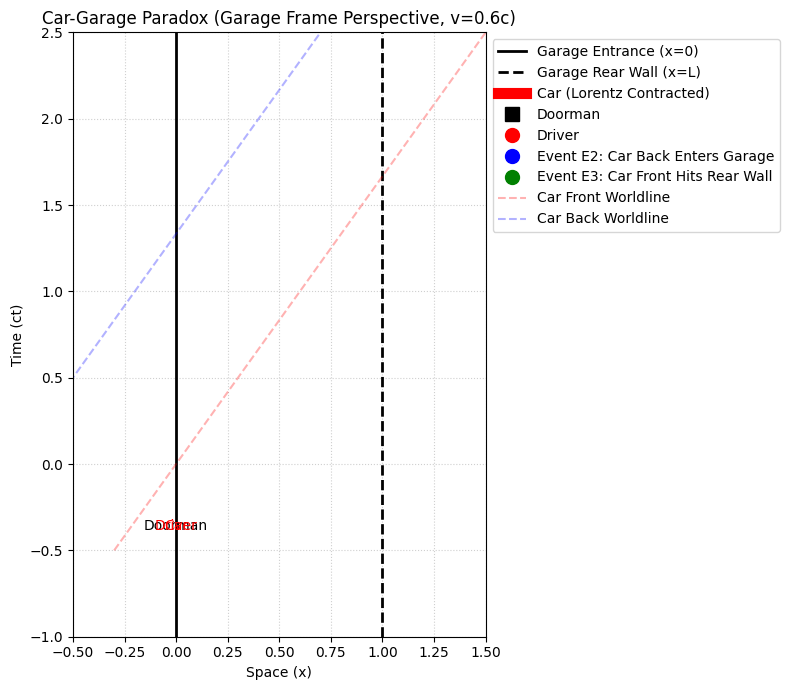

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Physical parameters
v = 0.6
gamma = 1 / np.sqrt(1 - v**2)
L = 1.0  # Proper length of garage and car

# Figure configuration
fig_garage, ax_garage = plt.subplots(figsize=(10, 7)) # Slightly larger figure
ax_garage.set_xlim(-0.5, L + 0.5) # Extend x-axis to show movement outside garage
ax_garage.set_ylim(-1.0, 2.5) # Extend time axis for longer animation
ax_garage.set_xlabel('Space (x)')
ax_garage.set_ylabel('Time (ct)') # Assuming c=1 for simplicity, so ct is just t

# Fixed Garage worldlines
ax_garage.plot([0, 0], [-1.0, 2.5], 'k-', linewidth=2, label='Garage Entrance (x=0)')
ax_garage.plot([L, L], [-1.0, 2.5], 'k--', linewidth=2, label='Garage Rear Wall (x=L)')

# Animated elements (Car, Driver, Doorman, Labels)
car_line_garage, = ax_garage.plot([], [], 'r-', linewidth=8, label='Car (Lorentz Contracted)')
doorman_marker_garage, = ax_garage.plot([], [], 'ks', markersize=10, label='Doorman')
driver_marker_garage, = ax_garage.plot([], [], 'ro', markersize=10, label='Driver')

# Text annotations for labels
doorman_label_garage = ax_garage.text(0, -0.9, 'Doorman', color='black', ha='center', va='bottom', fontsize=10)
driver_label_garage = ax_garage.text(0, -0.9, 'Driver', color='red', ha='center', va='bottom', fontsize=10)
car_text_label_garage = ax_garage.text(0, -0.9, 'Car', color='red', ha='center', va='bottom', fontsize=10)

# Event markers
event_E2_garage, = ax_garage.plot([], [], 'bo', markersize=10, label='Event E2: Car Back Enters Garage')
event_E3_garage, = ax_garage.plot([], [], 'go', markersize=10, label='Event E3: Car Front Hits Rear Wall')

# Event time text annotations
event_E2_time_text_garage = ax_garage.text(0.1, 0, '', color='blue', fontsize=9, ha='left', va='bottom')
event_E3_time_text_garage = ax_garage.text(L - 0.1, 0, '', color='green', fontsize=9, ha='right', va='bottom')

# Collision text
collision_text_garage = ax_garage.text(L / 2, L / v, 'COLLISION!', color='red', fontsize=20, ha='center', va='center', weight='bold', alpha=0.0)

# Calculate key times
L_contracted = L / gamma
t_car_front_enters_garage = 0.0 # Define t=0 when car front is at x=0
t_car_back_enters_garage = L_contracted / v # Event E2
t_car_front_hits_wall = L / v # Event E3

# Animation frames (time in garage frame)
# Build frames with a pause at collision time
t_min = -0.5
t_max = t_car_front_hits_wall + 1.0 # Extend a bit after collision
num_frames_before = 150
num_frames_pause = 40 # Longer pause
num_frames_after = 50

frames_before = np.linspace(t_min, t_car_front_hits_wall, num_frames_before, endpoint=False)
frames_pause = np.full(num_frames_pause, t_car_front_hits_wall)
frames_after = np.linspace(t_car_front_hits_wall, t_max, num_frames_after)
all_frames_garage = np.concatenate((frames_before, frames_pause, frames_after))

# Worldlines (for context, not animated objects)
# Car front worldline
ax_garage.plot([v*t for t in np.linspace(t_min, t_max, 100)], np.linspace(t_min, t_max, 100), 'r--', alpha=0.3, label='Car Front Worldline')
# Car back worldline
ax_garage.plot([v*t - L_contracted for t in np.linspace(t_min, t_max, 100)], np.linspace(t_min, t_max, 100), 'b--', alpha=0.3, label='Car Back Worldline')


def init_garage():
    car_line_garage.set_data([], [])
    doorman_marker_garage.set_data([], [])
    driver_marker_garage.set_data([], [])
    event_E2_garage.set_data([], [])
    event_E3_garage.set_data([], [])
    doorman_label_garage.set_position((0, -0.4)) # Initial position of text, adjust Y if needed
    driver_label_garage.set_position((0, -0.4))
    car_text_label_garage.set_position((0, -0.4))
    event_E2_time_text_garage.set_text('')
    event_E3_time_text_garage.set_text('')
    collision_text_garage.set_alpha(0.0)
    return car_line_garage, doorman_marker_garage, driver_marker_garage, doorman_label_garage, driver_label_garage, car_text_label_garage, event_E2_garage, event_E3_garage, event_E2_time_text_garage, event_E3_time_text_garage, collision_text_garage

def update_garage(t_garage):
    # Car position in garage frame
    x_car_front = v * t_garage
    x_car_back = v * t_garage - L_contracted

    # Draw the car as a line segment
    car_line_garage.set_data([x_car_back, x_car_front], [t_garage, t_garage])

    # Doorman is at x=0
    doorman_marker_garage.set_data([0], [t_garage])
    doorman_label_garage.set_position((0, t_garage + 0.1)) # Place label above marker

    # Driver is at the center of the car
    x_driver = x_car_back + L_contracted / 2
    driver_marker_garage.set_data([x_driver], [t_garage])
    driver_label_garage.set_position((x_driver, t_garage + 0.1)) # Place label above marker

    # Car label (at car's center)
    car_text_label_garage.set_position((x_driver, t_garage - 0.2)) # Place label below car

    # Mark Event E2: Car back enters garage (x=0)
    if abs(t_garage - t_car_back_enters_garage) < 0.05:
        event_E2_garage.set_data([0], [t_car_back_enters_garage])
        event_E2_time_text_garage.set_position((0.1, t_car_back_enters_garage + 0.05))
        event_E2_time_text_garage.set_text(f'E2: t={t_car_back_enters_garage:.2f}')
    else:
        event_E2_garage.set_data([], []) # Clear marker if not in event time
        event_E2_time_text_garage.set_text('')

    # Mark Event E3: Car front hits rear wall (x=L)
    if abs(t_garage - t_car_front_hits_wall) < 0.05:
        event_E3_garage.set_data([L], [t_car_front_hits_wall])
        event_E3_time_text_garage.set_position((L - 0.1, t_car_front_hits_wall + 0.05))
        event_E3_time_text_garage.set_text(f'E3: t={t_car_front_hits_wall:.2f}')
    else:
        event_E3_garage.set_data([], []) # Clear marker if not in event time
        event_E3_time_text_garage.set_text('')

    # Collision pause and text
    if t_garage == t_car_front_hits_wall: # Check for exact collision time for pause
        collision_text_garage.set_alpha(1.0) # Make text visible
    else:
        collision_text_garage.set_alpha(0.0) # Make text invisible

    return car_line_garage, doorman_marker_garage, driver_marker_garage, doorman_label_garage, driver_label_garage, car_text_label_garage, event_E2_garage, event_E3_garage, event_E2_time_text_garage, event_E3_time_text_garage, collision_text_garage

# Create animation for Garage Frame
ani_garage = FuncAnimation(fig_garage, update_garage, frames=all_frames_garage,
                           init_func=init_garage, blit=True, interval=50) # Interval is in ms

ax_garage.set_title(f"Car-Garage Paradox (Garage Frame Perspective, v={v}c)")
ax_garage.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Move legend outside plot area
ax_garage.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.8, 1]) # Adjust layout for legend
plt.show()

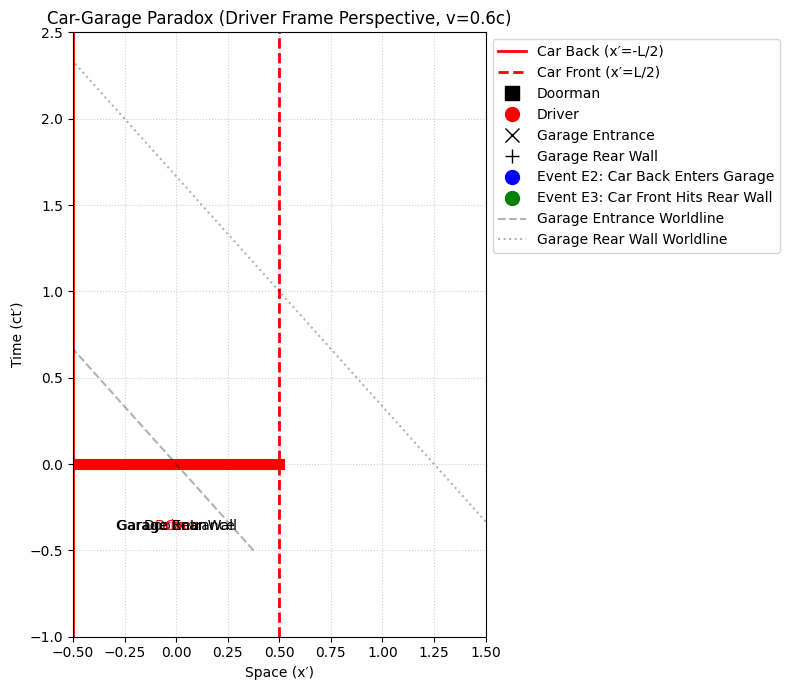

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Physical parameters
v = 0.6
gamma = 1 / np.sqrt(1 - v**2)
L = 1.0  # Proper length of garage and car

# Figure configuration for Driver Frame
fig_driver, ax_driver = plt.subplots(figsize=(10, 7)) # Slightly larger figure
ax_driver.set_xlim(-0.5, L + 0.5) # Extend x-axis to show movement outside garage
ax_driver.set_ylim(-1.0, 2.5) # Extend time axis for longer animation
ax_driver.set_xlabel('Space (x′)')
ax_driver.set_ylabel('Time (ct′)') # Assuming c=1 for simplicity, so ct' is just t'

# Fixed Garage worldlines in driver's frame (moving garage)
# Garage entrance (x'=gamma*(x-vt) => x'=gamma*(-vt) since x=0)
# Garage rear wall (x'=gamma*(x-vt) => x'=gamma*(L-vt) since x=L)

# Car worldlines in driver's frame (fixed car)
ax_driver.plot([-L/2, -L/2], [-1.0, 2.5], 'r-', linewidth=2, label='Car Back (x′=-L/2)')
ax_driver.plot([L/2, L/2], [-1.0, 2.5], 'r--', linewidth=2, label='Car Front (x′=L/2)')

# Animated elements (Car, Driver, Doorman, Labels)
# In driver's frame, car is stationary. Garage walls move.
car_line_driver, = ax_driver.plot([-L/2, L/2], [0, 0], 'r-', linewidth=8)

doorman_marker_driver, = ax_driver.plot([], [], 'ks', markersize=10, label='Doorman')
driver_marker_driver, = ax_driver.plot([], [], 'ro', markersize=10, label='Driver')
garage_front_marker_driver, = ax_driver.plot([], [], 'kx', markersize=10, label='Garage Entrance')
garage_back_marker_driver, = ax_driver.plot([], [], 'k+', markersize=10, label='Garage Rear Wall')

# Text annotations for labels
doorman_label_driver = ax_driver.text(0, -0.9, 'Doorman', color='black', ha='center', va='bottom', fontsize=10)
driver_label_driver = ax_driver.text(0, -0.9, 'Driver', color='red', ha='center', va='bottom', fontsize=10)
car_text_label_driver = ax_driver.text(0, -0.9, 'Car', color='red', ha='center', va='bottom', fontsize=10)
garage_front_label_driver = ax_driver.text(0, -0.9, 'Garage Entrance', color='black', ha='center', va='bottom', fontsize=10)
garage_back_label_driver = ax_driver.text(0, -0.9, 'Garage Rear Wall', color='black', ha='center', va='bottom', fontsize=10)

# Event markers
event_E2_driver, = ax_driver.plot([], [], 'bo', markersize=10, label='Event E2: Car Back Enters Garage')
event_E3_driver, = ax_driver.plot([], [], 'go', markersize=10, label='Event E3: Car Front Hits Rear Wall')

# Event time text annotations
event_E2_time_text_driver = ax_driver.text(-0.1, 0, '', color='blue', fontsize=9, ha='right', va='bottom')
event_E3_time_text_driver = ax_driver.text(0.1, 0, '', color='green', fontsize=9, ha='left', va='bottom')

# Collision text
collision_text_driver = ax_driver.text(0, L/v, 'COLLISION!', color='red', fontsize=20, ha='center', va='center', weight='bold', alpha=0.0)

# Calculate key times in driver's frame
L_proper = L # Car's length is proper in its own frame
L_contracted_garage = L / gamma # Garage length is contracted in driver's frame

# Events in garage frame:
# E1: Car front at garage entrance (x=0, t=0). In driver frame: x'=0, t'=0.
# E2: Car back at garage entrance (x=0, t=L_contracted/v). In driver frame:
#    x'_E2 = gamma * (0 - v * L_contracted / v) = -gamma * L_contracted = -L
#    t'_E2 = gamma * (L_contracted / v - v * 0) = gamma * L_contracted / v = L / v

# E3: Car front at garage rear wall (x=L, t=L/v). In driver frame:
#    x'_E3 = gamma * (L - v * L / v) = 0
#    t'_E3 = gamma * (L / v - v * L) = gamma * L * (1/v - v) = gamma * L / (gamma^2 * v) = L / (gamma * v)

t_E2_driver = L / v # Time in driver's frame when the event (car back at garage entrance) occurs at x'=-L
t_E3_driver = L / (gamma * v) # Time in driver's frame when the event (car front at garage rear wall) occurs at x'=0

# Animation frames (time in driver frame)
t_min_driver = -0.5 # Start before events
t_max_driver = t_E2_driver + 1.0 # Extend a bit after E2 (which is later than E3)

# Use same collision time for pause as the garage frame for consistency in event timing logic
# The actual collision is E3. So pause at t'_E3.
num_frames_before_driver = 150
num_frames_pause_driver = 40
num_frames_after_driver = 50

frames_before_driver = np.linspace(t_min_driver, t_E3_driver, num_frames_before_driver, endpoint=False)
frames_pause_driver = np.full(num_frames_pause_driver, t_E3_driver)
frames_after_driver = np.linspace(t_E3_driver, t_max_driver, num_frames_after_driver)
all_frames_driver = np.concatenate((frames_before_driver, frames_pause_driver, frames_after_driver))

# Worldlines for context
# Garage Entrance Worldline in driver's frame: x' = -gamma * v * t'
ax_driver.plot([-gamma * v * t_val for t_val in np.linspace(t_min_driver, t_max_driver, 100)],
               np.linspace(t_min_driver, t_max_driver, 100), 'k--', alpha=0.3, label='Garage Entrance Worldline')
# Garage Rear Wall Worldline in driver's frame: x' = gamma * (L - v * t')
ax_driver.plot([gamma * (L - v * t_val) for t_val in np.linspace(t_min_driver, t_max_driver, 100)],
               np.linspace(t_min_driver, t_max_driver, 100), 'k:', alpha=0.3, label='Garage Rear Wall Worldline')


def init_driver():
    car_line_driver.set_data([-L/2, L/2], [0, 0]) # Car is stationary in its own frame
    doorman_marker_driver.set_data([], [])
    driver_marker_driver.set_data([], [])
    garage_front_marker_driver.set_data([], [])
    garage_back_marker_driver.set_data([], [])
    event_E2_driver.set_data([], [])
    event_E3_driver.set_data([], [])
    doorman_label_driver.set_position((0, -0.4)) # Initial position of text
    driver_label_driver.set_position((0, -0.4))
    car_text_label_driver.set_position((0, -0.4))
    garage_front_label_driver.set_position((0, -0.4))
    garage_back_label_driver.set_position((0, -0.4))
    event_E2_time_text_driver.set_text('')
    event_E3_time_text_driver.set_text('')
    collision_text_driver.set_alpha(0.0)
    return car_line_driver, doorman_marker_driver, driver_marker_driver, garage_front_marker_driver, garage_back_marker_driver, doorman_label_driver, driver_label_driver, car_text_label_driver, garage_front_label_driver, garage_back_label_driver, event_E2_driver, event_E3_driver, event_E2_time_text_driver, event_E3_time_text_driver, collision_text_driver

def update_driver(t_driver):
    # Car is stationary at x'=0 (center)
    x_car_front_driver = L/2
    x_car_back_driver = -L/2

    # Car line is fixed, only its t' coordinate changes
    car_line_driver.set_data([x_car_back_driver, x_car_front_driver], [t_driver, t_driver])

    # Doorman position in driver's frame: x'_doorman = gamma * (0 - v * t_driver)
    x_doorman_driver = -gamma * v * t_driver
    doorman_marker_driver.set_data([x_doorman_driver], [t_driver])
    doorman_label_driver.set_position((x_doorman_driver, t_driver + 0.1))

    # Driver is at the center of the car in their own frame
    x_driver_pos = 0
    driver_marker_driver.set_data([x_driver_pos], [t_driver])
    driver_label_driver.set_position((x_driver_pos, t_driver + 0.1))
    car_text_label_driver.set_position((x_driver_pos, t_driver - 0.2))

    # Garage wall positions in driver's frame
    x_garage_front_driver = -gamma * v * t_driver
    x_garage_back_driver = gamma * (L - v * t_driver)

    garage_front_marker_driver.set_data([x_garage_front_driver], [t_driver])
    garage_front_label_driver.set_position((x_garage_front_driver, t_driver + 0.1))

    garage_back_marker_driver.set_data([x_garage_back_driver], [t_driver])
    garage_back_label_driver.set_position((x_garage_back_driver, t_driver + 0.1))

    # Mark Event E2: Car back enters garage (x=0, t=L_contracted/v in garage frame)
    # Transformed to driver's frame: (x'_E2 = -L, t'_E2 = L/v)
    if abs(t_driver - t_E2_driver) < 0.05:
        event_E2_driver.set_data([-L], [t_E2_driver]) # Mark at x'=-L (the transformed x-coordinate of E2)
        event_E2_time_text_driver.set_position((-L - 0.1, t_E2_driver + 0.05))
        event_E2_time_text_driver.set_text(f'E2: t′={t_E2_driver:.2f}')
    else:
        event_E2_driver.set_data([], [])
        event_E2_time_text_driver.set_text('')

    # Mark Event E3: Car front hits rear wall (x=L, t=L/v in garage frame)
    # Transformed to driver's frame: (x'_E3 = 0, t'_E3 = L/(gamma*v))
    if abs(t_driver - t_E3_driver) < 0.05:
        event_E3_driver.set_data([0], [t_E3_driver]) # Mark at x'=0 (the transformed x-coordinate of E3)
        event_E3_time_text_driver.set_position((0.1, t_E3_driver + 0.05))
        event_E3_time_text_driver.set_text(f'E3: t′={t_E3_driver:.2f}')
    else:
        event_E3_driver.set_data([], [])
        event_E3_time_text_driver.set_text('')

    # Collision pause and text
    if t_driver == t_E3_driver: # Check for exact collision time for pause
        collision_text_driver.set_alpha(1.0) # Make text visible
    else:
        collision_text_driver.set_alpha(0.0) # Make text invisible

    return car_line_driver, doorman_marker_driver, driver_marker_driver, garage_front_marker_driver, garage_back_marker_driver, doorman_label_driver, driver_label_driver, car_text_label_driver, garage_front_label_driver, garage_back_label_driver, event_E2_driver, event_E3_driver, event_E2_time_text_driver, event_E3_time_text_driver, collision_text_driver

# Create animation for Driver Frame
ani_driver = FuncAnimation(fig_driver, update_driver, frames=all_frames_driver,
                           init_func=init_driver, blit=True, interval=50) # Interval is in ms

ax_driver.set_title(f"Car-Garage Paradox (Driver Frame Perspective, v={v}c)")
ax_driver.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Move legend outside plot area
ax_driver.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.8, 1]) # Adjust layout for legend
plt.show()

### Comparison of Events in Garage and Driver Frames:

**1. The Doorman's Perspective (Garage Frame):**

*   **Event E2 (Car Back Enters Garage):** The doorman observes the car's back end entering the garage at time `t_car_back_enters_garage` (e.g., `t=1.33s` for v=0.6). At this moment, the car is Lorentz-contracted to a length `L/gamma`, which is shorter than the garage's proper length `L`. From the doorman's perspective, the *entire* car is momentarily inside the garage (or at least, the back has entered while the front has not yet hit the back wall).
*   **Event E3 (Car Front Hits Rear Wall):** The car's front hits the rear wall of the garage at `t_car_front_hits_wall` (e.g., `t=1.67s` for v=0.6). From the doorman's viewpoint, E2 happens *before* E3. This confirms the doorman's statement: the car fits inside the garage before it crashes.

**2. The Driver's Perspective (Driver Frame):**

*   **Car's Proper Length:** In the driver's frame, the car is at rest, so it has its proper length `L`. The garage, however, is moving and appears Lorentz-contracted to the driver. Its length is `L/gamma`.
*   **Event E3 (Car Front Hits Rear Wall):** The driver observes their car's front hitting the garage's rear wall at `t'_E3` (e.g., `t'=1.33s` for v=0.6). At this precise moment, the front of the car is at the contracted rear wall of the garage.
*   **Event E2 (Car Back Enters Garage):** The driver sees the garage's entrance passing their car's back end at a *later* time `t'_E2` (e.g., `t'=1.67s` for v=0.6). From the driver's viewpoint, E3 happens *before* E2. This means the car has already crashed through the back wall *before* its back end has even entered the garage!

**What Really Happens? (Relativity of Simultaneity):**

Both the doorman's and the driver's statements are correct *within their own inertial reference frames*. The key takeaway is the **relativity of simultaneity**: events that are simultaneous in one reference frame are generally *not* simultaneous in another frame moving relative to the first.

*   **Doorman's View:** Car contracts, fits entirely within the garage, then crashes.
*   **Driver's View:** Garage contracts, is too small for the car, and the car crashes through the back wall *before* the entire car enters the garage.

There is no single

In [8]:
from IPython.display import HTML

# To save the animations, uncomment the following lines:
ani_garage.save('garage_frame_simulation.gif', writer='pillow', fps=60)
ani_driver.save('driver_frame_simulation.gif', writer='pillow', fps=60)

# If you want to display the saved GIF in the notebook, you can use:
# HTML(ani_garage.to_jshtml())
# HTML(ani_driver.to_jshtml())

In [3]:
import numpy as np

v = 0.8  # v/c
gamma = 1 / np.sqrt(1 - v**2)
L = 1.0  # Longitud del garaje

# Matriz de Lorentz (2D para simplificar)
Lambda = np.array([
    [gamma, -v * gamma],
    [-v * gamma, gamma]
])

# Cuadrivectores en el garaje (ct, x)
Event_A_garage = np.array([0, L])
Event_B_garage = np.array([0, 0])

# Transformación matricial
Event_A_car = Lambda @ Event_A_garage
Event_B_car = Lambda @ Event_B_garage

print(f"Evento A en coche (ct', x'): {Event_A_car}")
print(f"Evento B en coche (ct', x'): {Event_B_car}")
print(f"Diferencia temporal (Delta t'): {Event_A_car[0] - Event_B_car[0]}")


Evento A en coche (ct', x'): [-1.33333333  1.66666667]
Evento B en coche (ct', x'): [0. 0.]
Diferencia temporal (Delta t'): -1.3333333333333337
